# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [3]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [4]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [5]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

In [6]:
#1
diabetes['feature_names']

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [7]:
#2


In [8]:
#3
diabetes['data'].shape[0]

442

#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [9]:
diabetes_data = diabetes['data']
diabetes_data.shape

(442, 10)

In [10]:
diabetes_target = diabetes['target']
diabetes_target.shape

(442,)

## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [11]:
from sklearn.linear_model import LinearRegression

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [12]:
diabetes_model = LinearRegression()

#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [15]:
from sklearn.model_selection import train_test_split
diabetes_data_train, diabetes_data_test, diabetes_target_train, diabetes_target_test = train_test_split(diabetes_data, diabetes_target, test_size=0.2, random_state=42)

Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

In [16]:
diabetes_model.fit(diabetes_data_train, diabetes_target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
print(diabetes_model.intercept_)

151.34560453985995


In [18]:
print(diabetes_model.coef_)

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [19]:
diabetes_prediction = diabetes_model.predict(diabetes_data_test)
diabetes_prediction

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858,  94.13865744, 168.43486358,
        53.5047888 , 206.63081659, 100.12925869, 130.66657085,
       219.53071499, 250.7803234 , 196.3688346 , 218.57511815,
       207.35050182,  88.48340941,  70.43285917, 188.95914235,
       154.8868162 , 159.36170122, 188.31263363, 180.39094033,
        47.99046561, 108.97453871, 174.77897633,  86.36406656,
       132.95761215, 184.53819483, 173.83220911, 190.35858492,
       124.4156176 , 119.65110656, 147.95168682,  59.05405241,
        71.62331856, 107.68284704, 165.45365458, 155.00975931,
       171.04799096,  61.45761356,  71.66672581, 114.96732206,
        51.57975523, 167.57599528, 152.52291955,  62.95568515,
       103.49741722, 109.20751489, 175.64118426, 154.60296242,
        94.41704366, 210.74209145, 120.2566205 ,  77.61585399,
       187.93203995, 206.49337474, 140.63167076, 105.59

#### Print your `diabetes_target_test` and compare with the prediction. 

In [20]:
diabetes_data_test

array([[ 0.04534098, -0.04464164, -0.00620595, -0.01599898,  0.1250187 ,
         0.1251981 ,  0.019187  ,  0.03430886,  0.03243232, -0.0052198 ],
       [ 0.09256398, -0.04464164,  0.03690653,  0.02187239, -0.02496016,
        -0.01665815,  0.00077881, -0.03949338, -0.02251653, -0.02178823],
       [ 0.06350368,  0.05068012, -0.00405033, -0.01255612,  0.10300346,
         0.04878988,  0.05600338, -0.00259226,  0.08449153, -0.01764613],
       [ 0.09619652, -0.04464164,  0.0519959 ,  0.07926471,  0.05484511,
         0.03657709, -0.07653559,  0.14132211,  0.09864806,  0.06105391],
       [ 0.01264814,  0.05068012, -0.02021751, -0.00222757,  0.03833367,
         0.05317395, -0.00658447,  0.03430886, -0.00514219, -0.00936191],
       [ 0.0090156 , -0.04464164, -0.02452876, -0.02632753,  0.0988756 ,
         0.0941964 ,  0.07072993, -0.00259226, -0.02139531,  0.00720652],
       [-0.00914709,  0.05068012,  0.17055523,  0.01498668,  0.03007796,
         0.03375875, -0.02131102,  0.03430886

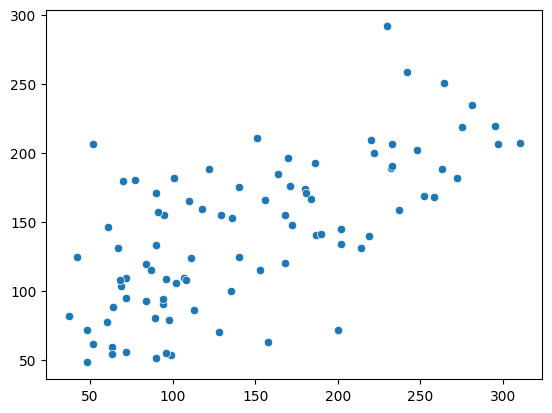

In [21]:
sns.scatterplot(x = diabetes_target_test, y = diabetes_prediction);

#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

In [22]:
from sklearn import metrics
import numpy as np

In [23]:
diabetes_model.score(diabetes_data_test, diabetes_target_test)

0.4526027629719197

In [24]:
print('MAE:', metrics.mean_absolute_error(diabetes_target_test, diabetes_prediction))
print('MSE:', metrics.mean_squared_error(diabetes_target_test, diabetes_prediction))
print('RMSE:', np.sqrt(metrics.mean_squared_error(diabetes_target_test, diabetes_prediction)))

MAE: 42.79409467959994
MSE: 2900.1936284934804
RMSE: 53.85344583676592


#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [25]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(diabetes_data_train)
X_test_scaled  = scaler.transform(diabetes_data_train)

diabetes_model_scaled = LinearRegression()
diabetes_model_scaled.fit(X_train_scaled, diabetes_target_train)
y_pred_scaled = diabetes_model_scaled.predict(X_test_scaled)

print(f"R² Score:     {diabetes_model_scaled.score(X_test_scaled, diabetes_target_test):.4f}")
print(f"MAE:          {metrics.mean_absolute_error(diabetes_target_test, y_pred_scaled):.2f}")
print(f"MSE:          {metrics.mean_squared_error(diabetes_target_test, y_pred_scaled):.2f}")
print(f"RMSE:         {np.sqrt(metrics.mean_squared_error(diabetes_target_test, y_pred_scaled)):.2f}")

ValueError: Found input variables with inconsistent numbers of samples: [89, 353]